In [15]:
import pandas as pd
from pathlib import Path

from papers_lab.io import Storage, PaperTransform
from papers_lab import PaperAnalysis
from eda import Visualizer


In [16]:
root = Path("papers")
store = Storage()

researches = []
for sub in ("ieee", "acm"):
    d = root / sub
    if d.exists():
        researches += store.load_dir(d, pattern="*.pkl", recursive=True)

len(researches)

2025-10-06 18:00:36,787 | ERROR | storage:iter_dir:line54 - Error loading papers/ieee/ieee_research_reverse_concept_nlp_0.pkl: No module named 'webscraping'
Traceback (most recent call last):
  File "/home/kenai/projects/vscode/lisa-llm-reqs/papers_lab/io/storage.py", line 52, in iter_dir
    yield self.load(p)
  File "/home/kenai/projects/vscode/lisa-llm-reqs/papers_lab/io/storage.py", line 34, in load
    pkl = pickle.load(f)
ModuleNotFoundError: No module named 'webscraping'
2025-10-06 18:00:36,789 | ERROR | storage:iter_dir:line54 - Error loading papers/ieee/ieee_research_reverse_static_uml_0.pkl: No module named 'webscraping'
Traceback (most recent call last):
  File "/home/kenai/projects/vscode/lisa-llm-reqs/papers_lab/io/storage.py", line 52, in iter_dir
    yield self.load(p)
  File "/home/kenai/projects/vscode/lisa-llm-reqs/papers_lab/io/storage.py", line 34, in load
    pkl = pickle.load(f)
ModuleNotFoundError: No module named 'webscraping'
2025-10-06 18:00:36,790 | ERROR | s

9

In [17]:
tx = PaperTransform()
df = tx.transform(researches, normalize_keywords=True)

pa = PaperAnalysis(df)

topkw = pa.top_keywords(20)
cooc = pa.cooccurrence_keywords(top_n=16)
kw_year = pa.keyword_trends(year_col="year", top_k=5)
auth_top = pa.author_frequency(top=3)
yr = pa.papers_per_year()
mo = pa.papers_per_month()
ym = pa.papers_per_year_month()
X = pa.bag_of_keywords()

In [32]:
# ver estatísticas básicas
# df.describe()
# df.shape
# df.head(40)

(23, 15)

In [19]:
viz = Visualizer(cmap_name="plasma", figsize=(11, 6))

In [20]:
viz.stats_table(df["n_keywords"])

,count,mean,std,min,25%,50%,75%,max
n_keywords,23.0,28.130435,12.106739,4.0,19.5,31.0,38.0,42.0


In [21]:
viz.stats_table(df["n_authors"])

,count,mean,std,min,25%,50%,75%,max
n_authors,23.0,3.695652,1.25896,2.0,3.0,3.0,4.0,7.0


In [22]:
viz.stats_table(df["n_abstract_words"])

,count,mean,std,min,25%,50%,75%,max
n_abstract_words,23.0,184.782609,56.579756,82.0,142.5,180.0,221.5,308.0


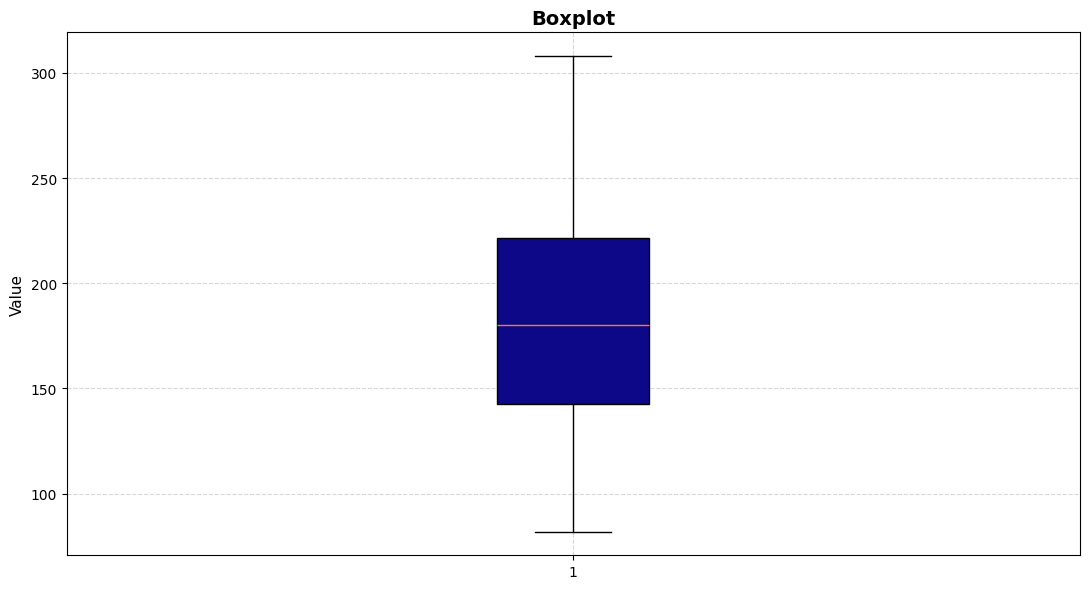

In [23]:
viz.boxplot(data=df["n_abstract_words"])

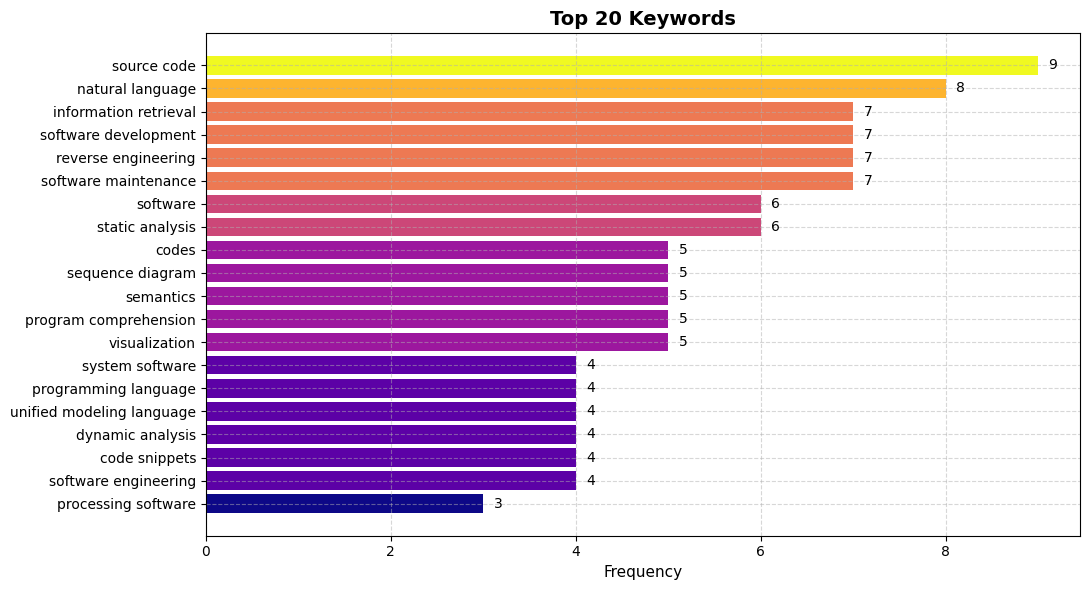

In [24]:
labels = topkw.index.tolist()
values = topkw.values.tolist()
viz.barh(labels, values, title=f"Top {len(values)} Keywords", xlabel="Frequency")


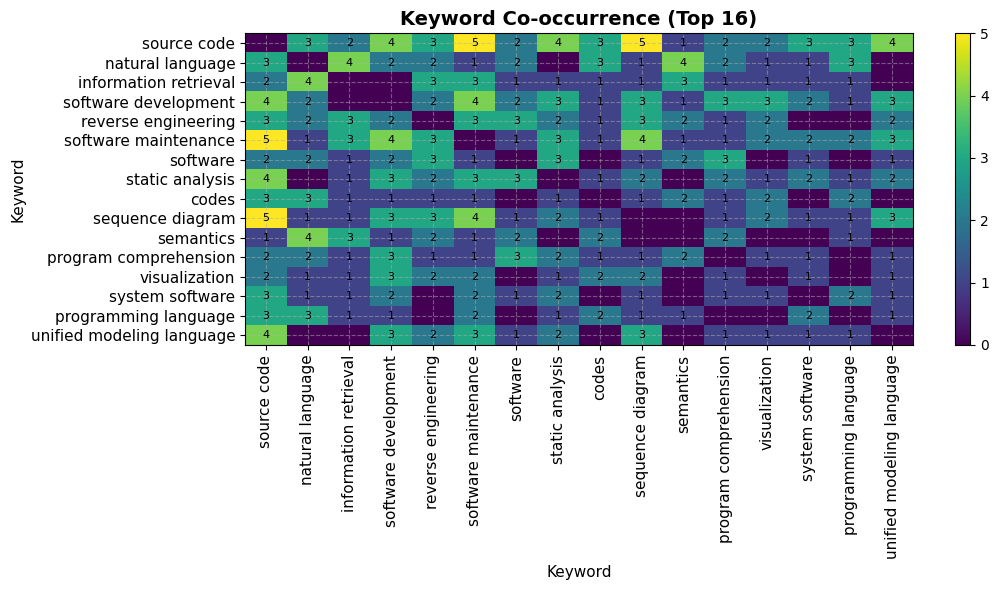

In [25]:
viz.heatmap(cooc, title="Keyword Co-occurrence (Top 16)", xlabel="Keyword", ylabel="Keyword", annotate=True)

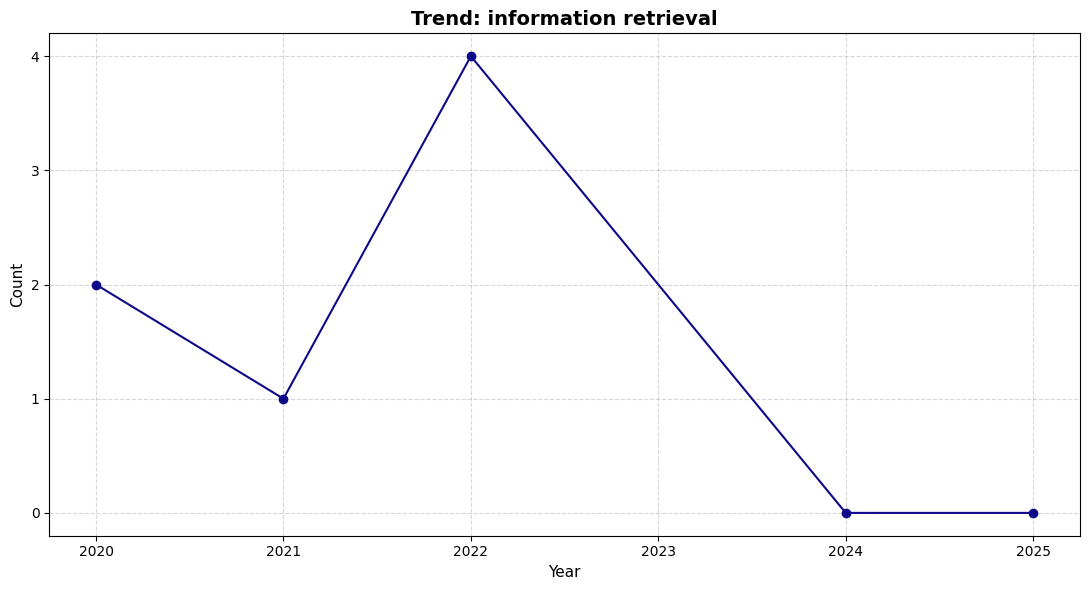

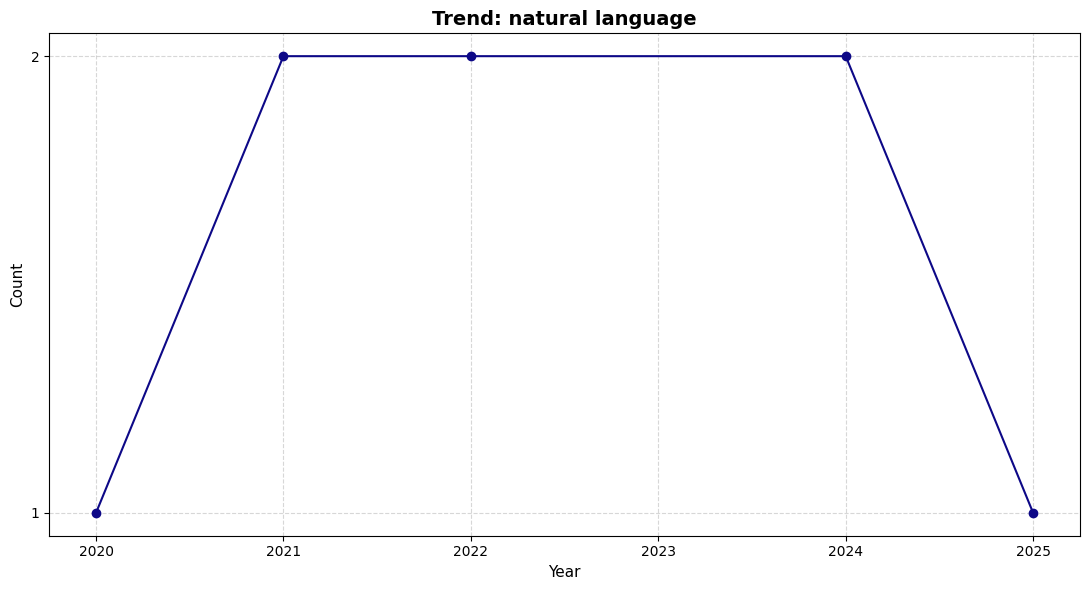

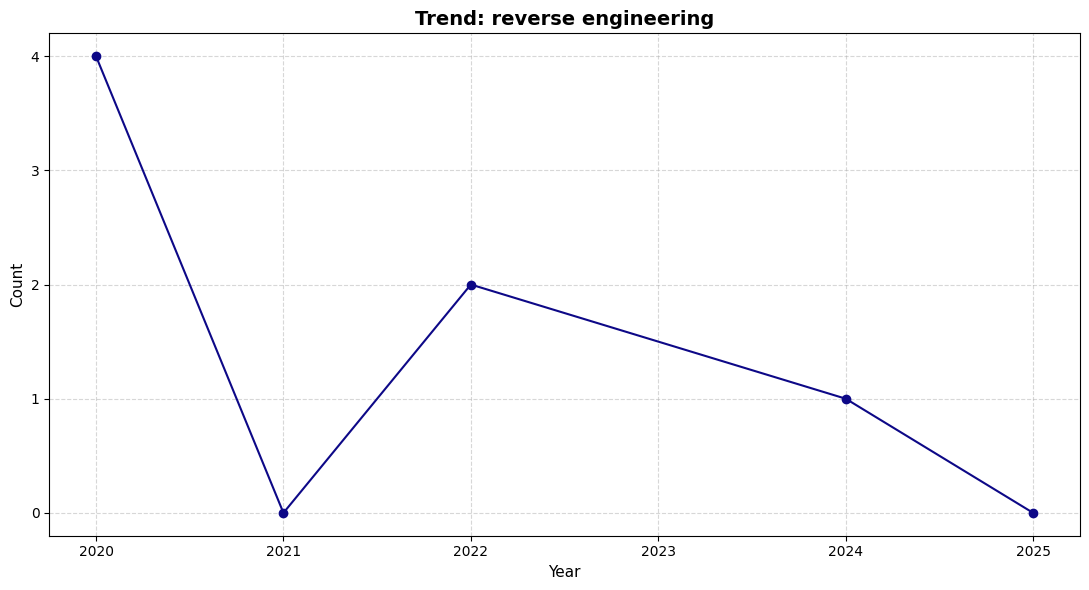

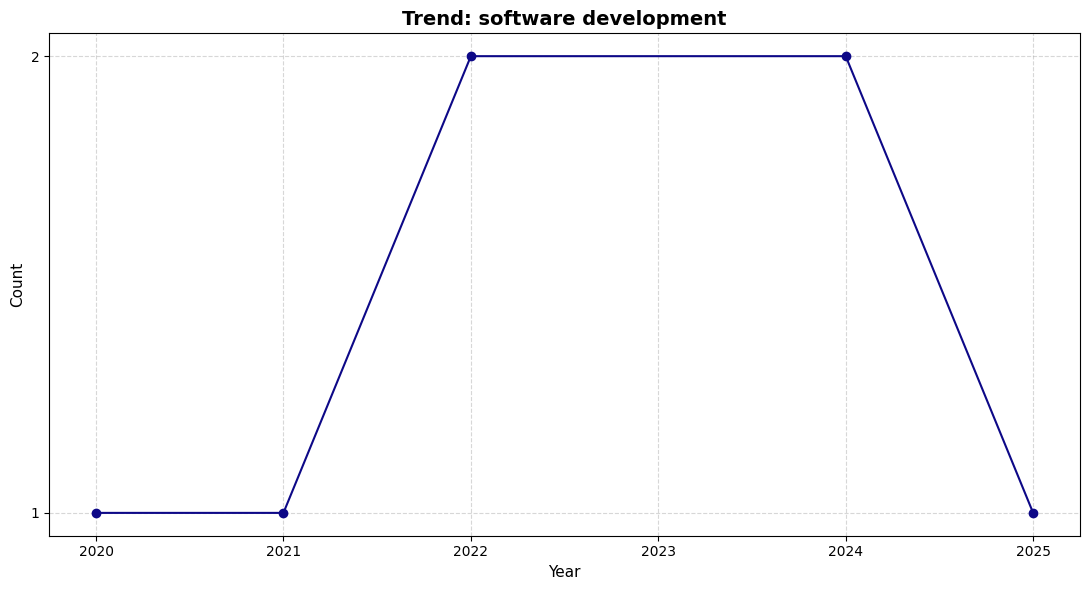

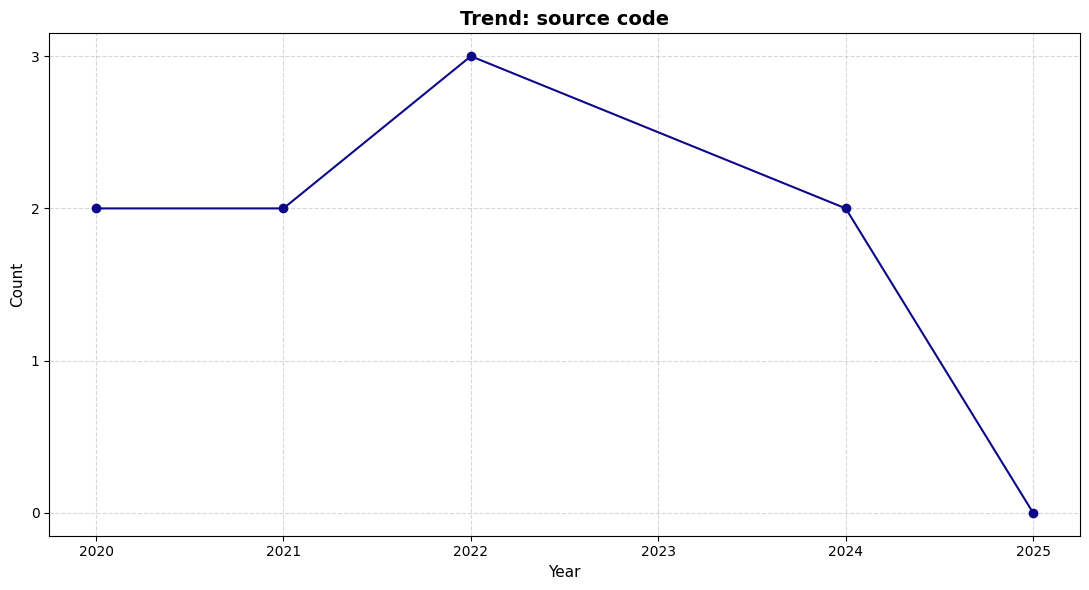

In [26]:
for kw in kw_year.columns:
    viz.line(kw_year.index, kw_year[kw].values, title=f"Trend: {kw}", xlabel="Year", ylabel="Count")

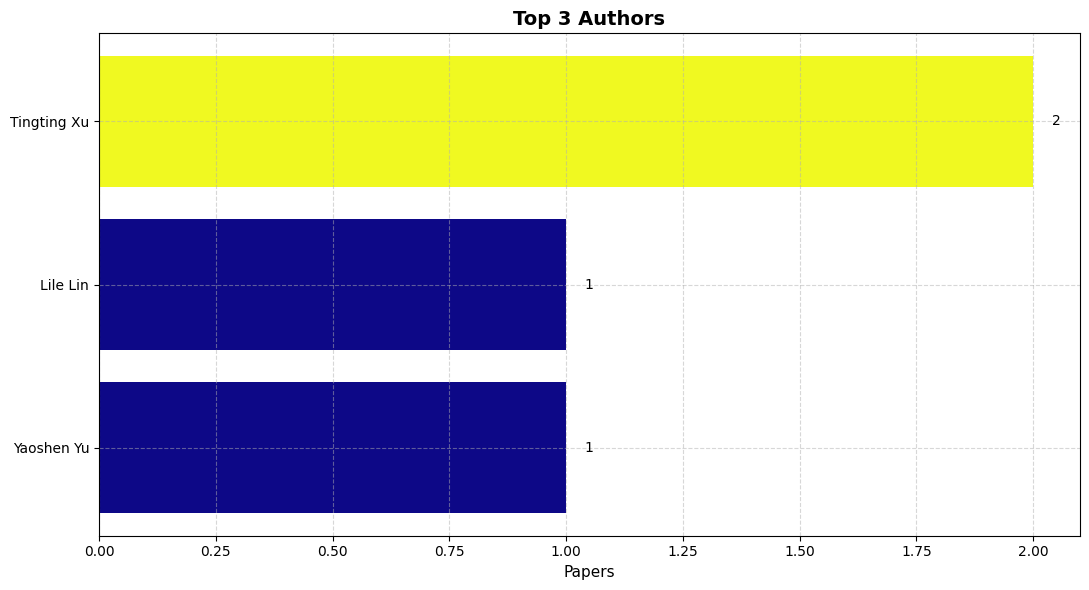

In [27]:
viz.barh(auth_top.index.tolist(), auth_top.values.tolist(),
         title=f"Top {len(auth_top)} Authors", xlabel="Papers")

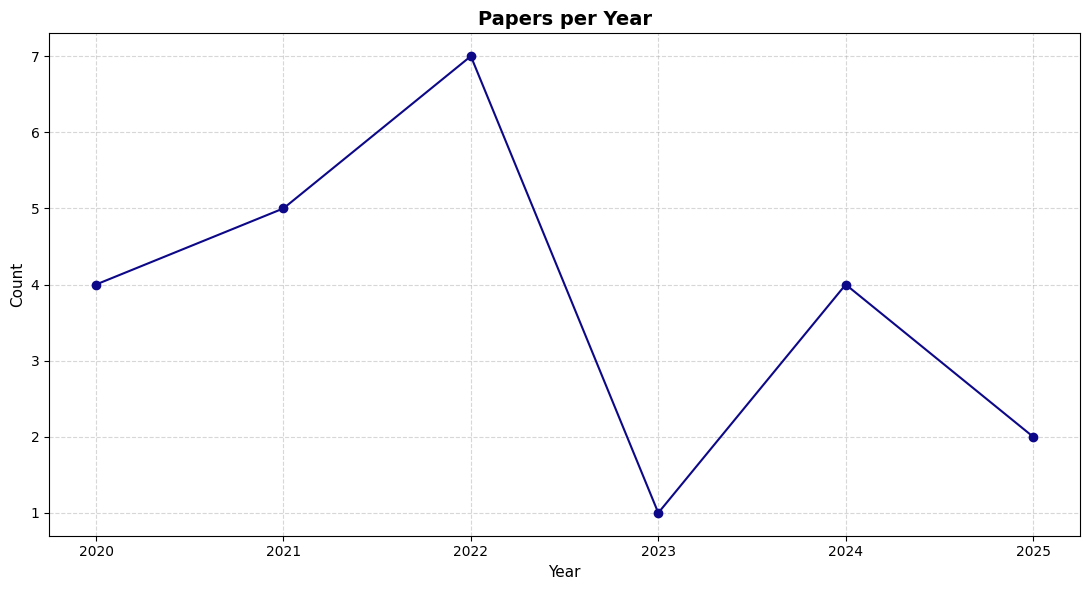

In [28]:
viz.line(yr.index.tolist(), yr.values.tolist(), title="Papers per Year", xlabel="Year", ylabel="Count")